MNIST数据集是图像分类中广泛使用的数据集之一，但作为基准数据集过于简单。我们将使用类似但更复杂的Fashion-MNIST数据集

In [3]:
pip install torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [5]:
torchvision.__version__

'0.29.0+cu132'

In [8]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils import data
from torchvision import transforms

通过框架内的内置函数将Fashion-MNIST的数据集下载并读取到内存中

In [9]:
#通过ToTensor实例将图像数据从PIL类型转换为32位浮点格式
#并除以255使所有像素值均在0到1之间
trans=transforms.ToTensor()#将图片转换为张量
mnist_train=torchvision.datasets.FashionMNIST(root="../data",train=True,transform=trans,download=True)#加载训练集
mnist_test=torchvision.datasets.FashionMNIST(root="../data",train=False,transform=trans,download=True)

len(mnist_train),len(mnist_test)

100.0%
100.0%
100.0%
100.0%


(60000, 10000)

查看图片形状

In [10]:
mnist_train[0][0].shape#取出第0个样本，大致得到（image，label），shape对应（通道数，高，宽）

torch.Size([1, 28, 28])

两个可视化数据集的函数

In [14]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels=['t-shirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bag','ankle boot']#方便用数字标签对应文本
    return [text_labels[int(i)] for i in labels]#交出文本

def show_images(imgs,num_rows,num_cols,titles=None,scale=1.5):
    """plot a list of images"""
    figsize=(num_cols*scale,num_rows*scale)
    _,axes=plt.subplots(num_rows,num_cols,figsize=figsize)#创建一个画布加多个子图
    axes=axes.flatten()#把二维结构变成一维
    for i,(ax,img) in enumerate(zip(axes,imgs)):#zip将两个列表配对
        if torch.is_tensor(img):
            #图片张量
            ax.imshow(img.numpy())#matplot的imshow主要接收numpy类似的数组
        else:
            #PIL图片
            ax.imshow(img)
        #隐藏坐标轴
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)

        # 显示标题
        if titles is not None:
            ax.set_title(titles[i])

几个样本的图像及其相应的标签

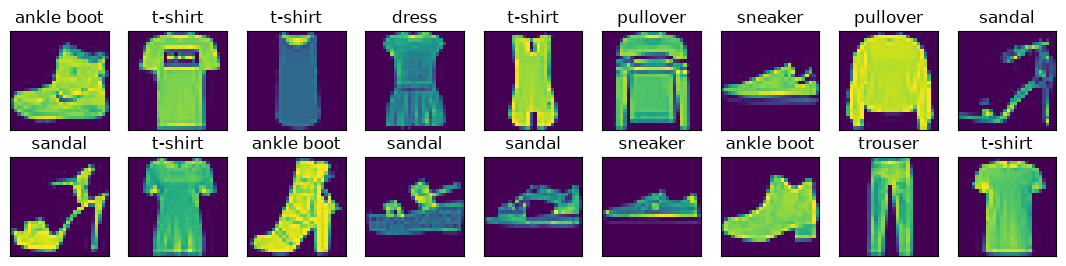

In [15]:
X,y=next(iter(data.DataLoader(mnist_train,batch_size=18)))#创建一个数据加载器，并进行迭代化，然后取出一个X，y->image,label
show_images(X.reshape(18,28,28),2,9,titles=get_fashion_mnist_labels(y))#原始tensor是[18,1,28,28]，把灰度表示去掉

读取一小批量数据，大小为batch_size

In [17]:
import time
batch_size=256

def get_dataloader_workers():#get_dataloader_workers=4
    """使用4个进程来读取数据"""
    return 3

train_iter=data.DataLoader(mnist_train,batch_size=batch_size,shuffle=True,num_workers=get_dataloader_workers())#多个线性工人同时处理
start=time.time()

for X,y in train_iter:#什么都不做就是为了测试读取速度
    continue
elapsed=time.time()-start
f'{elapsed:.2f} sec'

'6.91 sec'

In [19]:
X, y = next(iter(train_iter))

print(X.device)
print(y.device)

cpu
cpu
